## Estadistica Aplicada

Sesion 17 - 25 de Octubre

Bryan Alejandro Estrada Rodriguez 1844554

Grupo: 042


In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
%matplotlib inline

In [2]:
pip install pmdarima

     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 2.1/2.1 MB 22.1 MB/s eta 0:00:00


In [3]:
# Especializadas
from statsmodels.tsa.stattools import adfuller
from statsmodels.graphics.tsaplots import plot_acf, plot_pacf

# Importamos modelo ARIMA
from statsmodels.tsa.arima.model import ARIMA
from statsmodels.graphics.tsaplots import plot_predict


# pmdarima
import pmdarima as pm

In [5]:
desempleo_mex = pd.read_excel('desempleo_mex.xlsx')

In [6]:
desempleo_mex.dtypes

meses                 object
tasa de desempleo    float64
dtype: object

In [7]:
desempleo_mex.head()

,meses,tasa de desempleo
0,2005/01,3.951998
1,2005/02,3.773302
2,2005/03,3.627075
3,2005/04,3.363412
4,2005/05,3.303693


In [9]:
## convertir en tiempo
## hacerlo index
## asignarle frecuencia
desempleo_mex['meses'] = pd.to_datetime(desempleo_mex['meses'],format='%Y/%m')
desempleo_mex = desempleo_mex.set_index('meses')
desempleo_mex = desempleo_mex.asfreq('MS')

In [10]:
desempleo_mex.index

DatetimeIndex(['2005-01-01', '2005-02-01', '2005-03-01', '2005-04-01',
               '2005-05-01', '2005-06-01', '2005-07-01', '2005-08-01',
               '2005-09-01', '2005-10-01',
               ...
               '2022-11-01', '2022-12-01', '2023-01-01', '2023-02-01',
               '2023-03-01', '2023-04-01', '2023-05-01', '2023-06-01',
               '2023-07-01', '2023-08-01'],
              dtype='datetime64[ns]', name='meses', length=224, freq='MS')

In [11]:
## missing values
desempleo_mex.isnull().sum()

tasa de desempleo    0
dtype: int64

In [ ]:
## graficar la serie
desempleo_mex['tasa de desempleo'].plot(figsize=(12,6))
plt.xlabel('mes')
plt.ylabel('%')
plt.title('La tasa de desempleo en Mexico 2005-2023')
plt.show();


In [14]:
## prueba de Dicke-Fuller aumentada
prueba_adf = adfuller(desempleo_mex['tasa de desempleo'])
pvalue = prueba_adf[1]
pvalue.round(2)

0.25

No rechazamos H0, el desempleo es una serie no estacionaria, como no es una serie estacionaria hacemos priemeras diferencias

In [15]:
## primeras diferencias
desempleo_mex['desempleo_diff'] = desempleo_mex['tasa de desempleo'].diff()

In [ ]:
desempleo_mex['desempleo_diff'].plot()

In [19]:
prueba_adf1 = adfuller(desempleo_mex['desempleo_diff'].dropna())
pvalue1 = prueba_adf1[1]
pvalue1.round(2)

0.01

Rechazamos H0, las primeras diferencias de desempleo son una serie estacionaria

In [ ]:
## graficas de correlacion
ig, ax = plt.subplots(1,2, figsize=(10,4))
## 1er grafica
plot_acf(desempleo_mex['desempleo_diff'].dropna(),zero=False,lags=30,ax=ax[0])
## 2da grafica
plot_pacf(desempleo_mex['desempleo_diff'].dropna(),zero=False,lags=30,ax=ax[1])
plt.show();

Con las graficas de correlacion dado que emerge un patron que se repite, estamos ante una serie con componente escacional, es decir, hay meses que el desempleo siempre sube o meses que el desempleo siempre baja


Como tiene un componente estacional en este caso 12, 24, 36 se usa SARIMA

In [22]:
## Encotrar el orden del SARIMA

In [23]:
pm.auto_arima(desempleo_mex['tasa de desempleo'],
              start_p=1, start_q=1,
              max_p=10, max_q=10,
              ic='aic',
              seasonal=True,
              m=12,
              start_P=1,start_Q=1,
              max_P=7,max_Q=7

              )

ARIMA(order=(1, 1, 0), scoring_args={}, seasonal_order=(1, 0, 1, 12),
      suppress_warnings=True, with_intercept=False)

La tasa de desempleo es un SARIMA (1,1,0)(1,0,1,12)

In [50]:
## modelo
model = ARIMA(desempleo_mex['tasa de desempleo'],
               order=(1,1,0),
               seasonal_order=(1,0,1,12))
results = model.fit()
print(results.summary())

                                     SARIMAX Results                                      
Dep. Variable:                  tasa de desempleo   No. Observations:                  224
Model:             ARIMA(1, 1, 0)x(1, 0, [1], 12)   Log Likelihood                 -28.306
Date:                            Wed, 25 Oct 2023   AIC                             64.613
Time:                                    22:13:53   BIC                             78.241
Sample:                                01-01-2005   HQIC                            70.115
                                     - 08-01-2023                                         
Covariance Type:                              opg                                         
                 coef    std err          z      P>|z|      [0.025      0.975]
------------------------------------------------------------------------------
ar.L1         -0.3689      0.061     -6.075      0.000      -0.488      -0.250
ar.S.L12       0.9763      0.014   

In [51]:
desempleo_mex['desempleo_arima'] = results.predict()

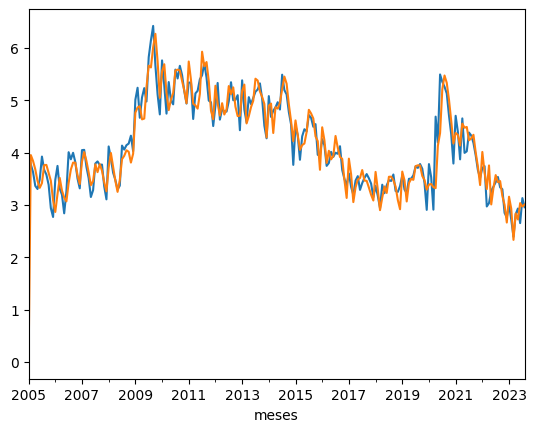

In [52]:
desempleo_mex['tasa de desempleo'].plot()
desempleo_mex['desempleo_arima'].plot();

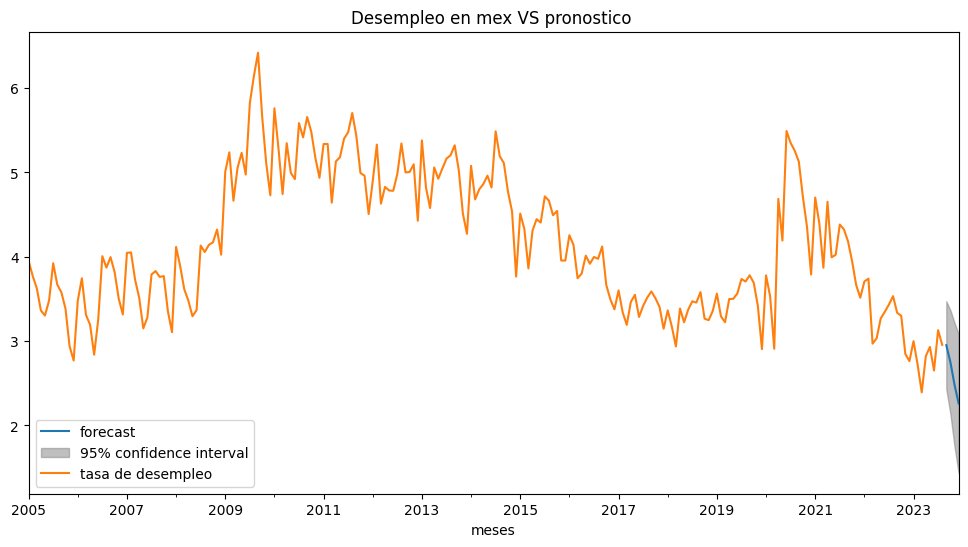

In [53]:
## grafica del pronostico futuro
plot_predict(results, '2023-09-01','2023-12-01')
desempleo_mex['tasa de desempleo'].plot(figsize=(12,6))
plt.title('Desempleo en mex VS pronostico ')
plt.legend(loc ='lower left')
plt.show()

In [54]:
forecast = results.get_forecast(steps=4)
forecast_mean = forecast.predicted_mean
forecast_ci = forecast.conf_int()

In [55]:
inicio = '2023-09-01'
fin = '2023-12-01'


In [56]:
pronostico_valor = forecast_mean[inicio:fin]
pronosticar_intervalos = forecast_ci.loc[inicio:fin]


In [57]:
pro_desempleo = pd.DataFrame({
'pronostico':pronostico_valor,
'limite inferior':pronosticar_intervalos.iloc[:,0],
'limite superior':pronosticar_intervalos.iloc[:,1]
})

In [58]:
pro_desempleo

,pronostico,limite inferior,limite superior
2023-09-01,2.951736,2.431391,3.472082
2023-10-01,2.750668,2.135374,3.365962
2023-11-01,2.483561,1.750114,3.217008
2023-12-01,2.262439,1.439564,3.085313


In [59]:
print(f'Para septiembre pronosticamos una tasa de desempleo de {pro_desempleo.iloc[0,0].round(2)}% pero puede estar entre {pro_desempleo.iloc[0,1].round(2)} y {pro_desempleo.iloc[0,2].round(2)}% cpm 95% de confianza ')

Para septiembre pronosticamos una tasa de desempleo de 2.95% pero puede estar entre 2.43 y 3.47% cpm 95% de confianza 
